In [18]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base
from Kea.statistics.spectra import strfn_spectra, spectra_base
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

N = 256
L = 2.*np.pi
grid_dims = (N, N)
phys_dims = (L, L)


/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:73: RuntimeWarning: divide by zero encountered in power
  terms.append((xx/bb[0])**(-a[0]))
/home/m/Documents/science_codes/Kea/Kea/simulator/fbm.py:62: RuntimeWarning: invalid value encountered in multiply
  output = np.sqrt(output * C)


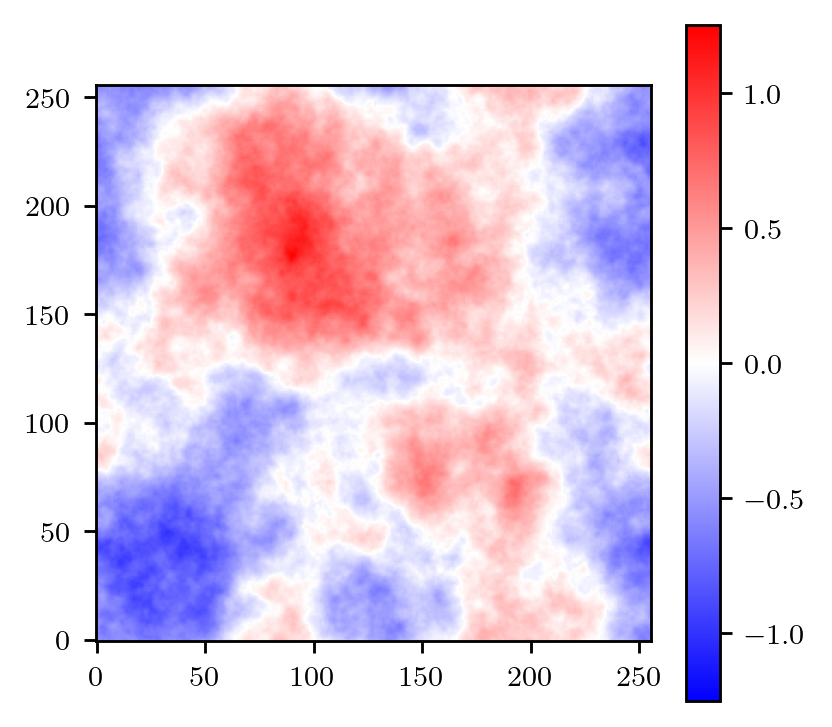

In [19]:
np.random.seed(1234)
x2 = fbm.create_fbm(grid_dims, phys_dims, (-3.5,), (1.,))
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
im = ax.imshow(x2, origin='lower', cmap='bwr', vmin=-np.max(np.abs(x2)), vmax=np.max(np.abs(x2)))
fig.colorbar(im)

In [20]:
lv2 = statfunc_base.get_all_lagvecs([2*n+1 for n in x2.shape])
sf2 = strfn.process_lags(x2, x2, lv2, periodic=True, lenn=(2.*np.pi, 2.*np.pi), shape=tuple([2*n+1 for n in x2.shape]), orders=[2])[0]
#ssim_ks, ssim_feks, _ = spectra_base.calculate_integrated_spectrum((ssim_sf2,), method='strfn', spec_type='modal', int_kwargs=int_kwargs, lenn=L)
#ssim_i_sf = strfn_spectra.interpolate(ssim_ks, ssim_feks, ssim_k)
#lv = statfunc_base.get_all_lagvecs(x2.shape)
#strfn.process_lags(x2, x2, lv, (2.*np.pi, 2.*np.pi), (256, 256))

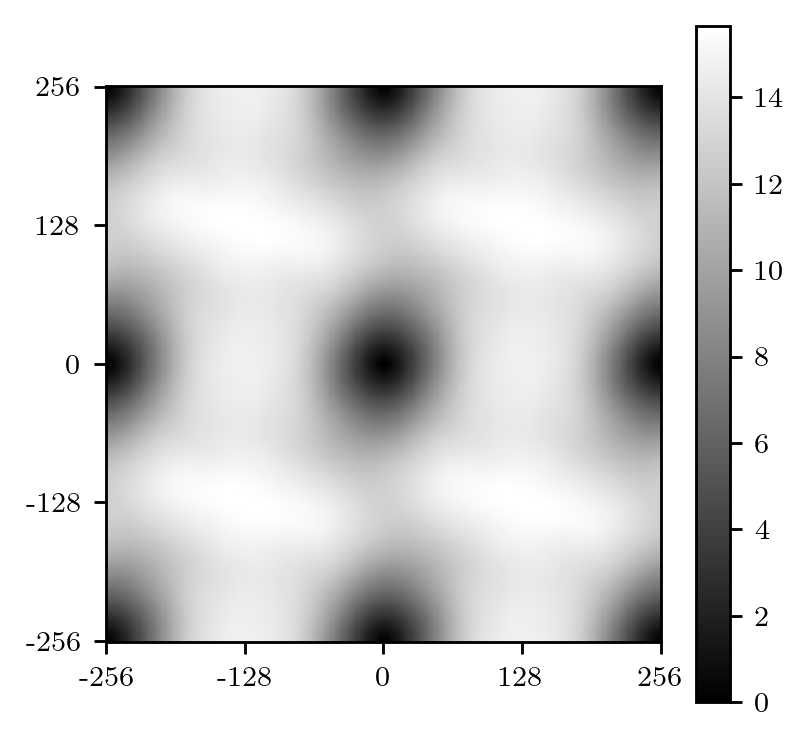

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)
im = ax.imshow(sf2, origin='lower', cmap='gist_gray', interpolation='none')
ax.set_xticks([0, N//2, N, 3.*N//2, 2.*N], [-N, -N//2, 0, N//2, N])
ax.set_yticks([0, N//2, N, 3.*N//2, 2.*N], [-N, -N//2, 0, N//2, N])
fig.colorbar(im)

In [22]:
def omni_spectrum_2(ar, n=None, lenn=None):
    if lenn is None:
        lenn = 2.*np.pi
    if n is None:
        n = statfunc_base.get_lagvec_magnitude_array(ar.shape)
    n, sf1d, _ = statistics_base.bin_data(
        n, ar, mean_func=np.nanmean, min_bin=1., cut_excess=True, ignore_nan=True, norm_bin_size=False)

    N = len(n)

    dx = lenn/N
    dk = 2.*np.pi / lenn

    kk = 2.*np.pi / (dx*n)

    dS = np.gradient(sf1d)

    ell = dx * n
    dell = np.gradient(ell)

    fek = (dk / (2. * np.pi))**ar.ndim * (1./(8.*np.pi)) * (2.*np.pi)**ar.ndim * (ell)**2 * (dS/dell)
    #fek = (dk / (2. * np.pi))**ar.ndim * (ell)**2 * (dS/dell)
    return kk[::-1], fek[::-1]

In [23]:
k, fek = omni_spectrum_2(sf2)

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [24]:
kp, fekp, _ = spectra_base.calculate_integrated_spectrum([x2,], spec_type='omni', lenn=(L, L))
ks, feks, _ = spectra_base.calculate_integrated_spectrum([sf2,], spec_type='omni', method='strfn', lenn=L)

/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


/home/m/Documents/science_codes/Kea/Kea/statistics/spectra/strfn_spectra.py:32: RuntimeWarning: invalid value encountered in log10
  f_int = interp1d(np.log10(k_sf), np.log10(fek_sf), kind='linear', fill_value='extrapolate')


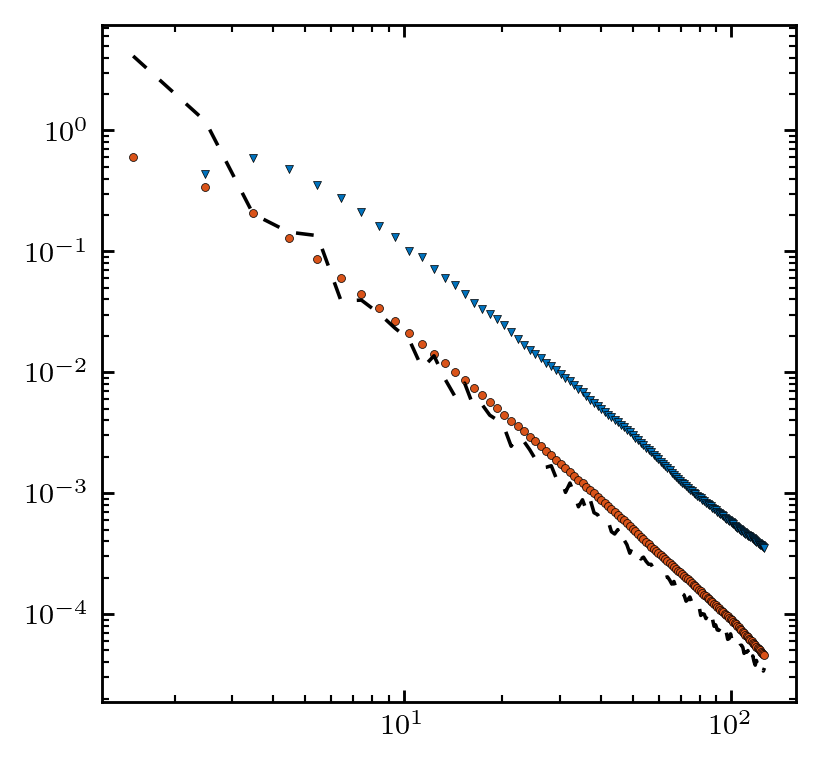

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

c = plotting.COLOR_CYCLE_6

ax.plot(kp, fekp, linewidth=1., linestyle=(0,(5,5)), color='black')
#ax.scatter(k, fek, color=c[0], s=5., marker='v', edgecolor='black', linewidth=0.2)

i_sf_fek = strfn_spectra.interpolate(k, fek, kp)
ax.scatter(kp, i_sf_fek, color=c[0], s=5., marker='v', edgecolor='black', linewidth=0.2)

#ax.scatter(ks, feks, color=c[1], s=5., marker='o', edgecolor='black', linewidth=0.2)

i_sf_fekold = strfn_spectra.interpolate(ks, feks, kp)
i_sf_fekold = i_sf_fekold/(2.5)
ax.scatter(kp, i_sf_fekold, color=c[1], s=5., marker='o', edgecolor='black', linewidth=0.2)

ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_ylim((1e-8, 1e0))

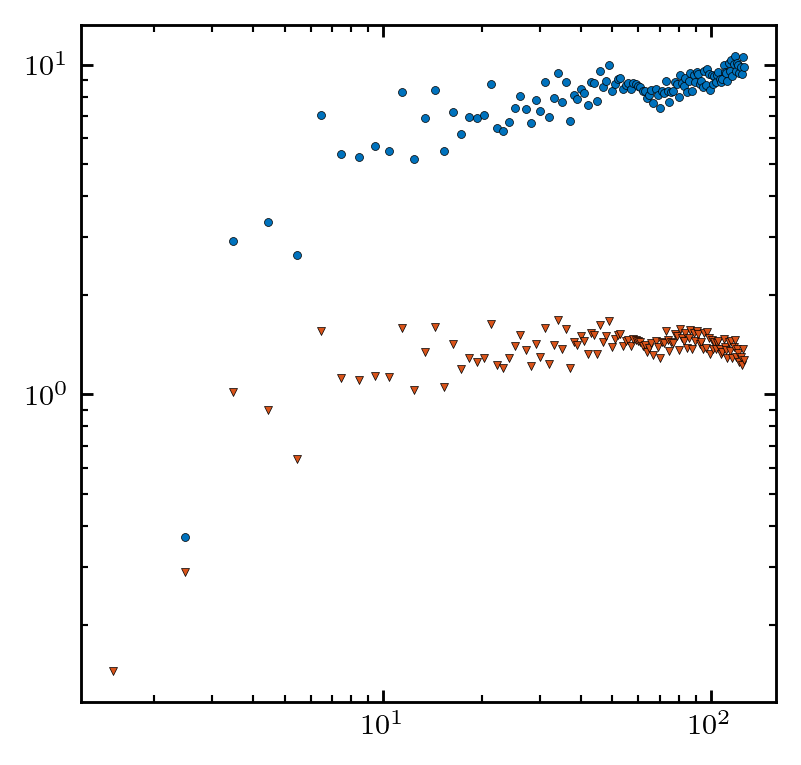

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')

ax.scatter(kp, i_sf_fek / fekp, marker='o', s=5., linewidth=0.2, edgecolor='black', color=c[0])
ax.scatter(kp, i_sf_fekold / fekp, marker='v', s=5., linewidth=0.2, edgecolor='black', color=c[1])

ax.set_xscale('log')
ax.set_yscale('log')

-2.2080631606884653 -2.6666666666666665


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[]

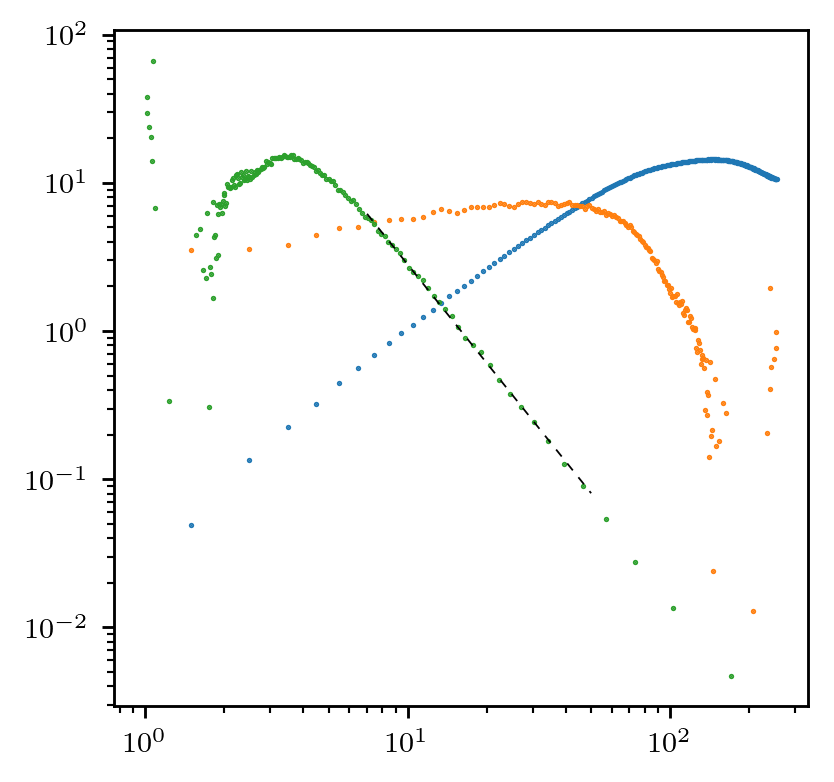

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

nar = statfunc_base.get_lagvec_magnitude_array(sf2.shape)
nar, sf1d, _ = statistics_base.bin_data(nar, sf2, mean_func=np.nanmean, min_bin=1., cut_excess=True, ignore_nan=True, norm_bin_size=False)

ax.scatter(nar, sf1d, marker='.', s=1.)

dS = np.gradient(sf1d)
ax.scatter(nar, dS/np.gradient(nar * L/N), marker='.', s=1.)

k_eff = 2.*np.pi/(nar * L/N)
k_eff = k_eff[::-1]
fek_eff = (L/N * nar)**2 * dS/np.gradient(nar * L/N)
fek_eff = fek_eff[::-1]

ax.scatter(k_eff, fek_eff, marker='.', s=1.)

z, xx, p = fit_base.fit_powerlaw(k_eff, fek_eff, 7., 50.)
print(z[0], -11./3. + 2 - 1)

ax.plot(xx, p, linestyle=(0,(5,5)), linewidth=0.5, color='black')

ax.loglog()


In [28]:
print(sf1d[-1], np.max(sf1d), np.sum(fekp))

10.571962005597626 14.408786451214633 6.062603340730572
